# 04 — Explainability Analysis
**Project:** ViT Reliability & Explainability Under Medical Distribution Shift
**Author:** Sosna Worku

**Continues from:** `03_distribution_shift.ipynb`

**Goal:** Visualize and evaluate ViT attention maps and ResNet GradCAM under distribution shift.

**Research Question:**
- RQ3: Do ViT attention maps remain clinically meaningful when tested on OOD data?

---
Run all cells top to bottom every new Colab session.

## 0. Setup — Run every session

In [1]:
import os, sys

REPO_PATH = '/content/vit-medical-shift'
GITHUB    = 'https://github.com/sossyh/vit-medical-shift.git'

if os.path.exists(REPO_PATH):
    os.system(f'git -C {REPO_PATH} pull origin main')
else:
    os.system(f'git clone {GITHUB} {REPO_PATH}')

sys.path.insert(0, REPO_PATH)
print('Repo ready!')

Repo ready!


In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted!')

Mounted at /content/drive
Drive mounted!


In [3]:
!pip install -q timm torchmetrics grad-cam einops pyyaml
print('Packages ready!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 42.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 63.7 MB/s eta 0:00:00
Packages ready!


In [4]:
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')

GPU: Tesla T4


## 1. Paths & Device

In [5]:
from src.utils import get_device, set_seed

set_seed(42)
device = get_device()

NIH_CSV   = '/content/drive/MyDrive/data/nih/Data_Entry_2017.csv'
NIH_IMGS  = '/content/drive/MyDrive/data/nih/images'
BBOX_CSV  = '/content/drive/MyDrive/data/nih/BBox_List_2017.csv'
CHEX_CSV  = '/content/drive/MyDrive/data/chexpert/valid.csv'
CHEX_IMGS = '/content/drive/MyDrive/data/chexpert/PNG_valid_files'
VIT_CKPT  = '/content/drive/MyDrive/checkpoints/vit_nih/best.pth'
RES_CKPT  = '/content/drive/MyDrive/checkpoints/resnet_nih/best.pth'

print('ViT checkpoint:', os.path.exists(VIT_CKPT))
print('BBox CSV      :', os.path.exists(BBOX_CSV))
print('CheXpert imgs :', os.path.exists(CHEX_IMGS))

Using GPU: Tesla T4
ViT checkpoint: True
BBox CSV      : True
CheXpert imgs : True


## 2. Load Models

In [6]:
from src.model import get_vit, get_resnet

vit_model = get_vit(num_classes=14, pretrained=False).to(device)
vit_model.load_state_dict(torch.load(VIT_CKPT, map_location=device))
vit_model.eval()
print('ViT loaded!')

resnet_model = get_resnet(num_classes=14, pretrained=False).to(device)
resnet_model.load_state_dict(torch.load(RES_CKPT, map_location=device))
resnet_model.eval()
print('ResNet loaded!')

ViT loaded!
ResNet loaded!


## 3. Load Sample Images — ID (NIH) and OOD (CheXpert)

In [7]:
import pandas as pd
import numpy as np
from PIL import Image
from src.dataset import get_transforms
from src.utils import NIH_LABELS

transform = get_transforms('val')

# Load NIH BBox CSV
bbox_df = pd.read_csv(BBOX_CSV)
print('BBox findings:', bbox_df['Finding Label'].unique())

# Pick 4 NIH images with bounding boxes
id_samples = []
for finding in ['Cardiomegaly', 'Atelectasis', 'Effusion', 'Pneumonia']:
    rows = bbox_df[bbox_df['Finding Label'] == finding]
    for _, row in rows.iterrows():
        img_path = os.path.join(NIH_IMGS, row['Image Index'])
        if os.path.exists(img_path):
            img = Image.open(img_path).convert('RGB')
            id_samples.append({
                'image'   : img,
                'tensor'  : transform(img),
                'finding' : finding,
                'bbox_row': row,
                'filename': row['Image Index']
            })
            print(f'Loaded ID: {finding} — {row["Image Index"]}')
            break

# Pick 4 CheXpert images
chex_df = pd.read_csv(CHEX_CSV)
chex_df = chex_df[chex_df['Frontal/Lateral'] == 'Frontal'].reset_index(drop=True)
chex_df['local_path'] = chex_df['Path'].apply(lambda p: '/'.join(p.split('/')[-3:]))
chex_df['local_path'] = chex_df['local_path'].str.replace('.jpg', '.png', regex=False)

ood_samples = []
for _, row in chex_df.iterrows():
    if len(ood_samples) >= 4:
        break
    img_path = os.path.join(CHEX_IMGS, row['local_path'])
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('RGB')
        ood_samples.append({
            'image'  : img,
            'tensor' : transform(img),
            'finding': 'CheXpert OOD',
        })
        print(f'Loaded OOD: {row["local_path"]}')

print(f'\nLoaded {len(id_samples)} ID samples, {len(ood_samples)} OOD samples')

BBox findings: ['Atelectasis' 'Cardiomegaly' 'Effusion' 'Infiltrate' 'Mass' 'Nodule'
 'Pneumonia' 'Pneumothorax']
Loaded ID: Cardiomegaly — 00019018_007.png
Loaded ID: Atelectasis — 00013118_008.png
Loaded ID: Effusion — 00010172_001.png
Loaded ID: Pneumonia — 00011136_002.png
Loaded OOD: patient64541/study1/view1_frontal.png
Loaded OOD: patient64542/study1/view1_frontal.png
Loaded OOD: patient64543/study1/view1_frontal.png
Loaded OOD: patient64544/study1/view1_frontal.png

Loaded 4 ID samples, 4 OOD samples


## 4. Compute ViT Attention Maps

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from src.explainability import (
    get_attention_maps, attention_rollout,
    resize_attention, overlay_attention, denormalise
)

def compute_vit_attention(model, tensor, device):
    attn_maps = get_attention_maps(model, tensor, device)
    mask      = attention_rollout(attn_maps)
    mask      = resize_attention(mask, target_size=224)
    return mask

# ID attention maps
print('Computing ViT attention for ID samples...')
id_attention = []
for s in id_samples:
    mask = compute_vit_attention(vit_model, s['tensor'], device)
    id_attention.append(mask)
    print(f'  Done: {s["finding"]}')

# OOD attention maps
print('\nComputing ViT attention for OOD samples...')
ood_attention = []
for s in ood_samples:
    mask = compute_vit_attention(vit_model, s['tensor'], device)
    ood_attention.append(mask)
    print(f'  Done: OOD sample')

print('All attention maps computed!')

Computing ViT attention for ID samples...
  Done: Cardiomegaly
  Done: Atelectasis
  Done: Effusion
  Done: Pneumonia

Computing ViT attention for OOD samples...
  Done: OOD sample
  Done: OOD sample
  Done: OOD sample
  Done: OOD sample
All attention maps computed!


## 5. Visualize Attention Maps — ID vs OOD

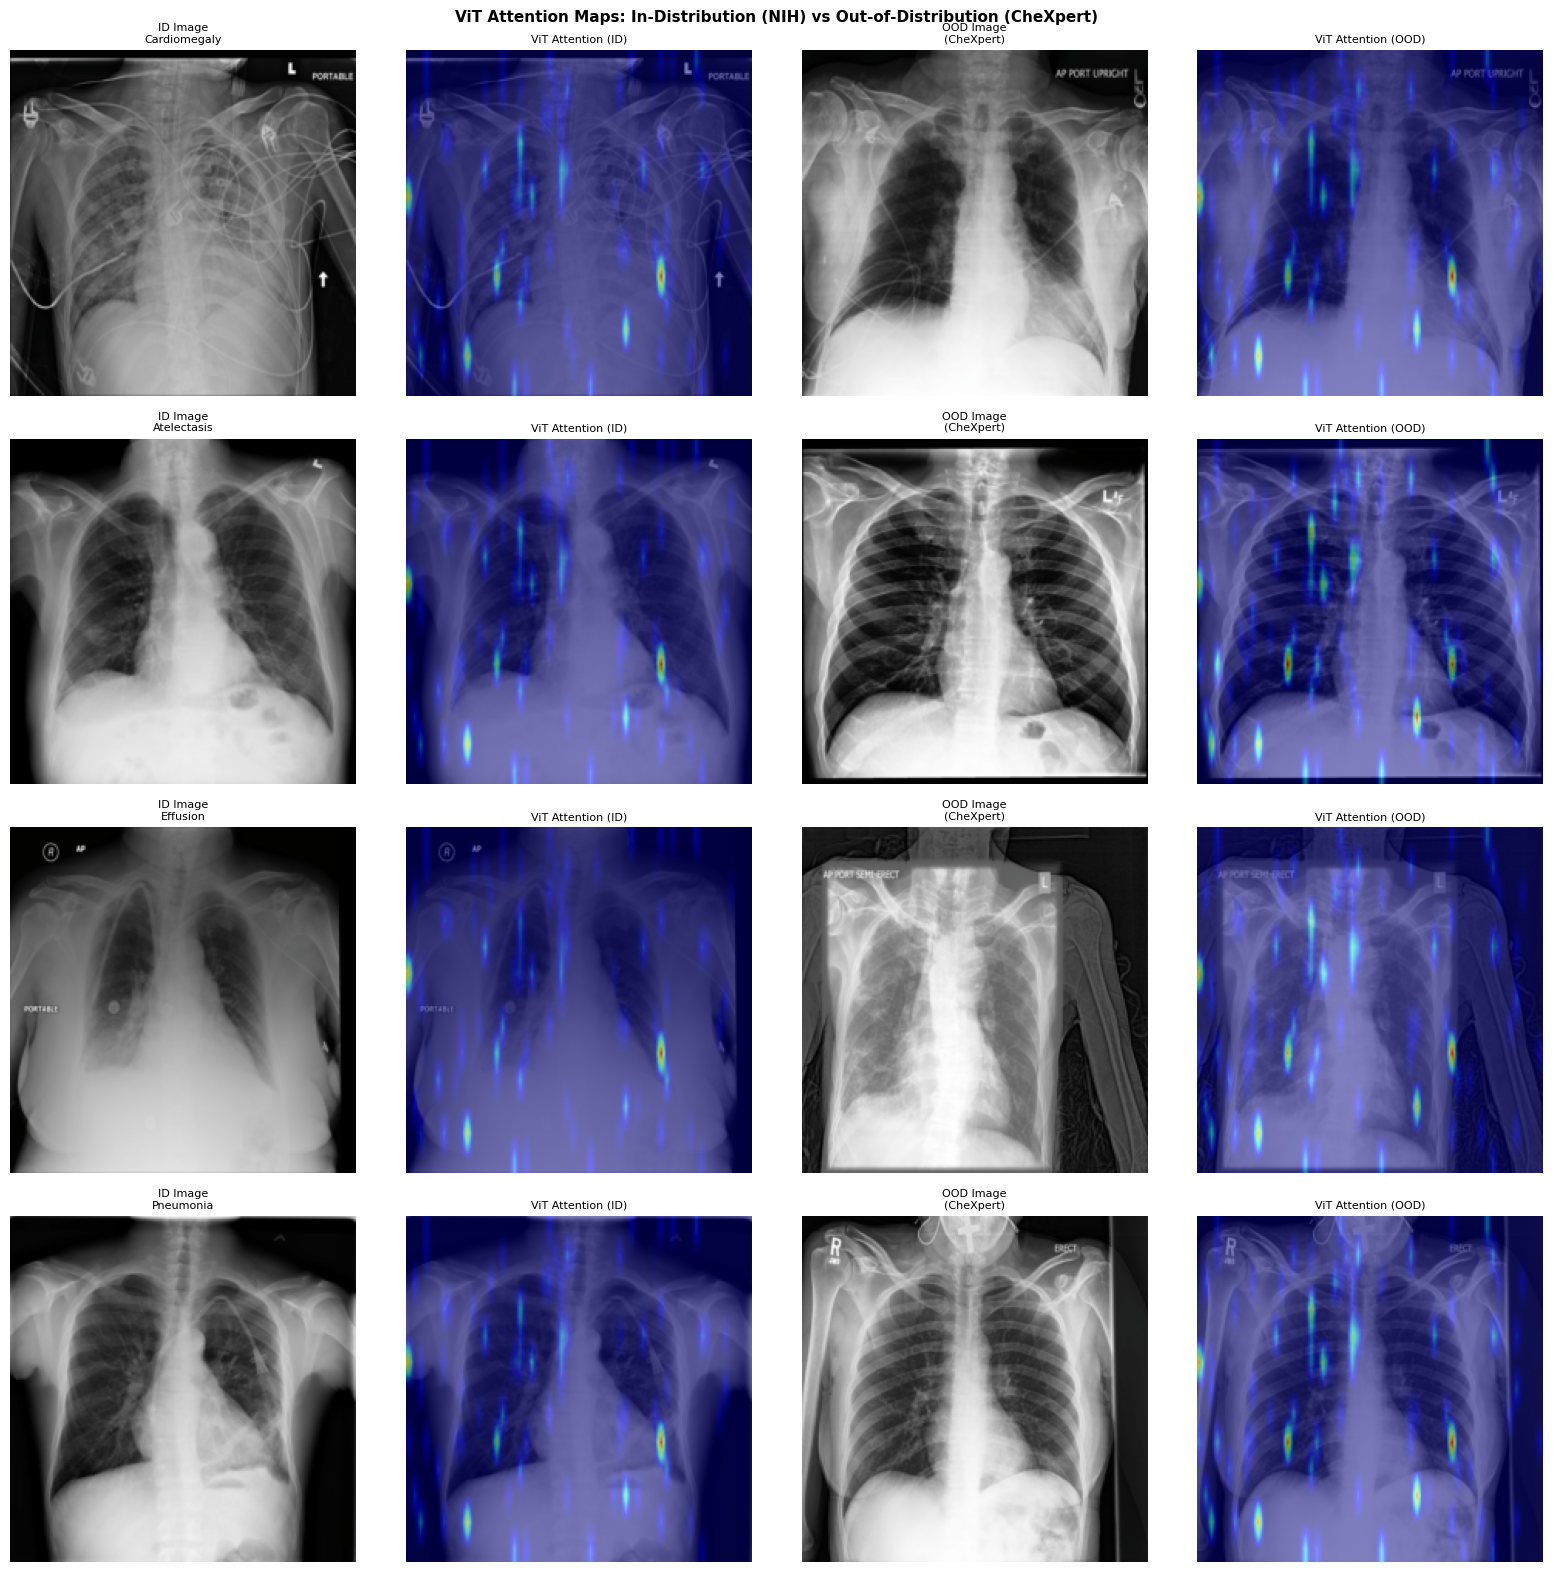

Saved!


In [9]:
n = min(len(id_samples), len(ood_samples), 4)
fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))

for i in range(n):
    id_img  = denormalise(id_samples[i]['tensor'])
    ood_img = denormalise(ood_samples[i]['tensor'])

    axes[i, 0].imshow(id_img, cmap='gray')
    axes[i, 0].set_title(f'ID Image\n{id_samples[i]["finding"]}', fontsize=8)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(overlay_attention(id_img, id_attention[i]))
    axes[i, 1].set_title('ViT Attention (ID)', fontsize=8)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(ood_img, cmap='gray')
    axes[i, 2].set_title('OOD Image\n(CheXpert)', fontsize=8)
    axes[i, 2].axis('off')

    axes[i, 3].imshow(overlay_attention(ood_img, ood_attention[i]))
    axes[i, 3].set_title('ViT Attention (OOD)', fontsize=8)
    axes[i, 3].axis('off')

plt.suptitle('ViT Attention Maps: In-Distribution (NIH) vs Out-of-Distribution (CheXpert)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
os.makedirs(f'{REPO_PATH}/results/figures', exist_ok=True)
plt.savefig(f'{REPO_PATH}/results/figures/attention_id_vs_ood.png', dpi=150)
plt.show()
print('Saved!')

## 6. GradCAM for ResNet

In [10]:
from src.explainability import get_gradcam

target_layer = resnet_model.layer4[-1]

print('Computing GradCAM for ID samples...')
id_gradcam = []
for s in id_samples:
    label_idx = NIH_LABELS.index(s['finding']) if s['finding'] in NIH_LABELS else 0
    cam = get_gradcam(resnet_model, s['tensor'], label_idx, target_layer, device)
    id_gradcam.append(cam)
    print(f'  Done: {s["finding"]}')

print('\nComputing GradCAM for OOD samples...')
ood_gradcam = []
for s in ood_samples:
    cam = get_gradcam(resnet_model, s['tensor'], 0, target_layer, device)
    ood_gradcam.append(cam)
    print(f'  Done: OOD sample')

print('GradCAM done!')

Computing GradCAM for ID samples...
  Done: Cardiomegaly
  Done: Atelectasis
  Done: Effusion
  Done: Pneumonia

Computing GradCAM for OOD samples...
  Done: OOD sample
  Done: OOD sample
  Done: OOD sample
  Done: OOD sample
GradCAM done!


## 7. ViT Attention vs ResNet GradCAM vs Ground Truth

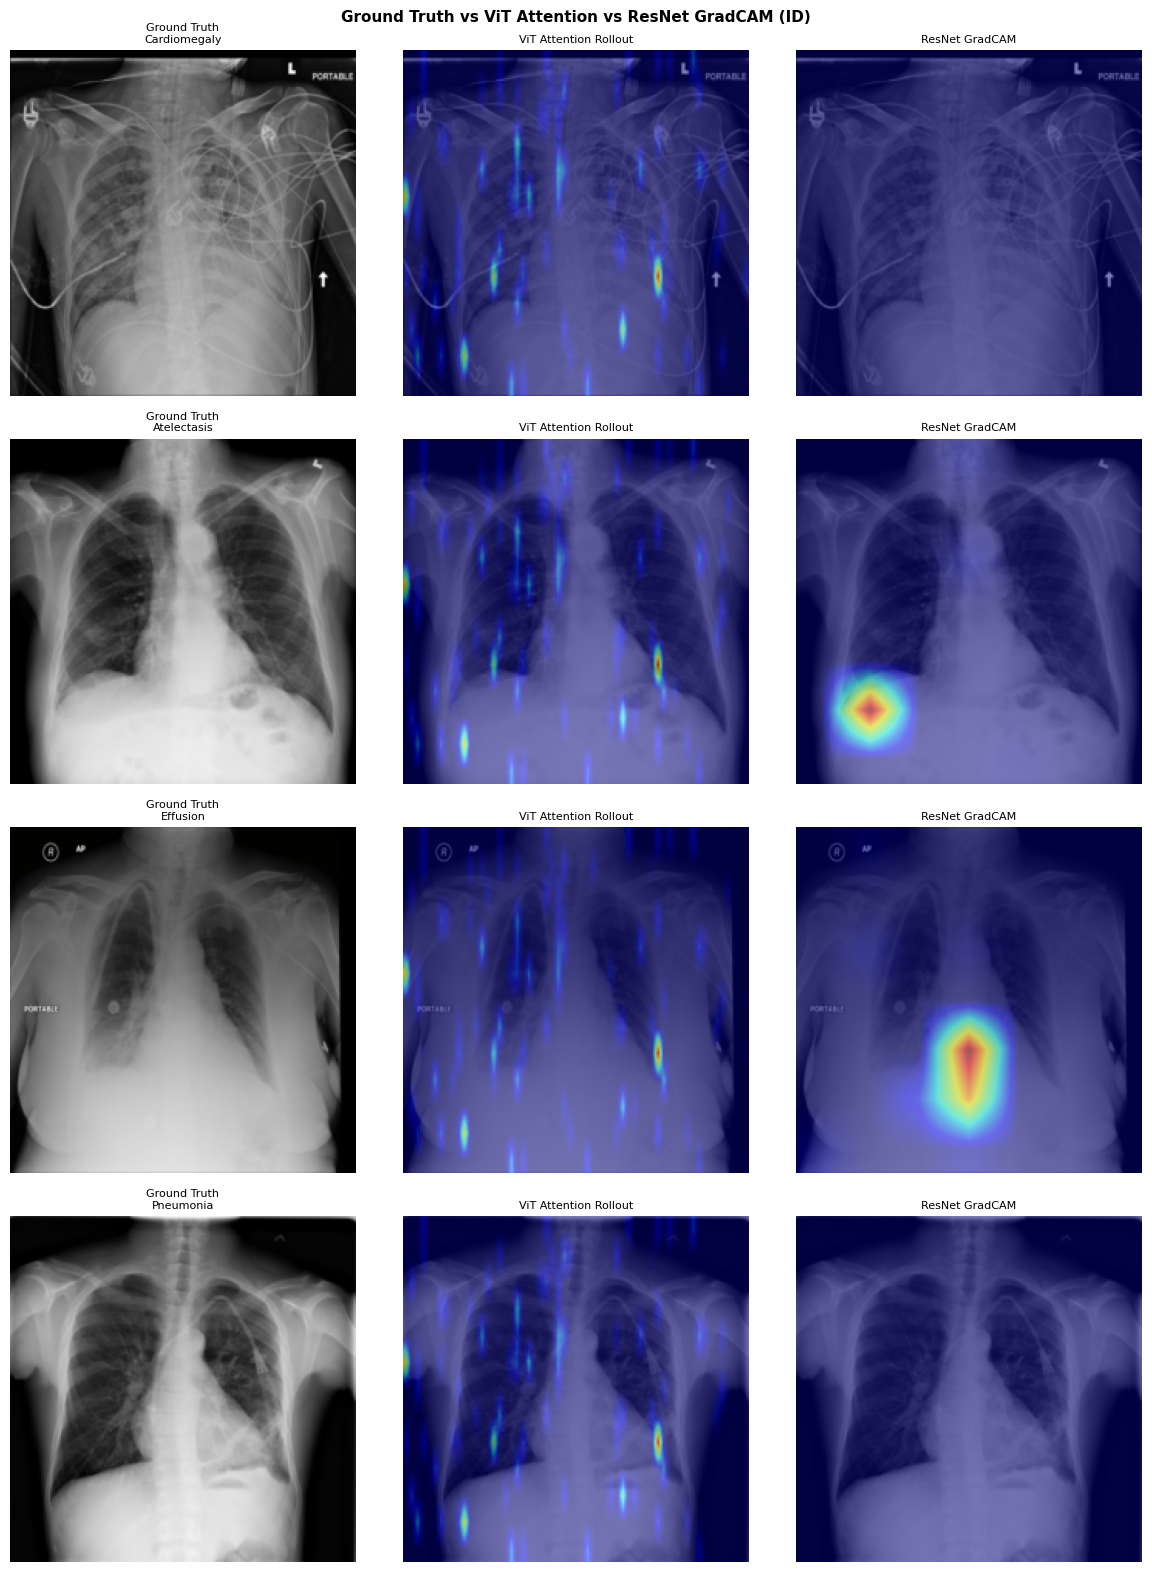

Saved!


In [11]:
n = len(id_samples)
fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))

for i in range(n):
    img = denormalise(id_samples[i]['tensor'])
    row = id_samples[i]['bbox_row']

    # Col 0: Original with ground truth bbox
    axes[i, 0].imshow(img, cmap='gray')
    x, y, w, h = row['Bbox [x'], row['y'], row['w'], row['h]']
    rect = patches.Rectangle((x, y), w, h,
                               linewidth=2, edgecolor='red', facecolor='none')
    axes[i, 0].add_patch(rect)
    axes[i, 0].set_title(f'Ground Truth\n{id_samples[i]["finding"]}', fontsize=8)
    axes[i, 0].axis('off')

    # Col 1: ViT attention
    axes[i, 1].imshow(overlay_attention(img, id_attention[i]))
    axes[i, 1].set_title('ViT Attention Rollout', fontsize=8)
    axes[i, 1].axis('off')

    # Col 2: ResNet GradCAM
    axes[i, 2].imshow(overlay_attention(img, id_gradcam[i]))
    axes[i, 2].set_title('ResNet GradCAM', fontsize=8)
    axes[i, 2].axis('off')

plt.suptitle('Ground Truth vs ViT Attention vs ResNet GradCAM (ID)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPO_PATH}/results/figures/vit_vs_resnet_xai.png', dpi=150)
plt.show()
print('Saved!')

## 8. IoU with Ground Truth Bounding Boxes

In [12]:
from src.explainability import compute_iou_with_bbox

iou_results = []
for i, s in enumerate(id_samples):
    row = s['bbox_row']
    vit_iou    = compute_iou_with_bbox(id_attention[i], row, threshold=0.5)
    resnet_iou = compute_iou_with_bbox(id_gradcam[i],   row, threshold=0.5)
    iou_results.append({
        'Finding'   : s['finding'],
        'ViT IoU'   : round(vit_iou, 3),
        'ResNet IoU': round(resnet_iou, 3)
    })
    print(f'{s["finding"]:20} ViT IoU={vit_iou:.3f}  ResNet IoU={resnet_iou:.3f}')

iou_df = pd.DataFrame(iou_results)
print(f'\nMean ViT IoU   : {iou_df["ViT IoU"].mean():.3f}')
print(f'Mean ResNet IoU: {iou_df["ResNet IoU"].mean():.3f}')

Cardiomegaly         ViT IoU=0.000  ResNet IoU=0.000
Atelectasis          ViT IoU=0.000  ResNet IoU=0.000
Effusion             ViT IoU=0.000  ResNet IoU=0.000
Pneumonia            ViT IoU=0.000  ResNet IoU=0.000

Mean ViT IoU   : 0.000
Mean ResNet IoU: 0.000


## 9. Save Results & Download

In [13]:
from google.colab import files

os.makedirs(f'{REPO_PATH}/results/metrics', exist_ok=True)

iou_df.to_csv(f'{REPO_PATH}/results/metrics/iou_results.csv', index=False)
print('Saved IoU results!')

files.download(f'{REPO_PATH}/results/figures/attention_id_vs_ood.png')
files.download(f'{REPO_PATH}/results/figures/vit_vs_resnet_xai.png')
files.download(f'{REPO_PATH}/results/metrics/iou_results.csv')
print('Done! Copy to repo and git push from VS Code.')

Saved IoU results!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Copy to repo and git push from VS Code.


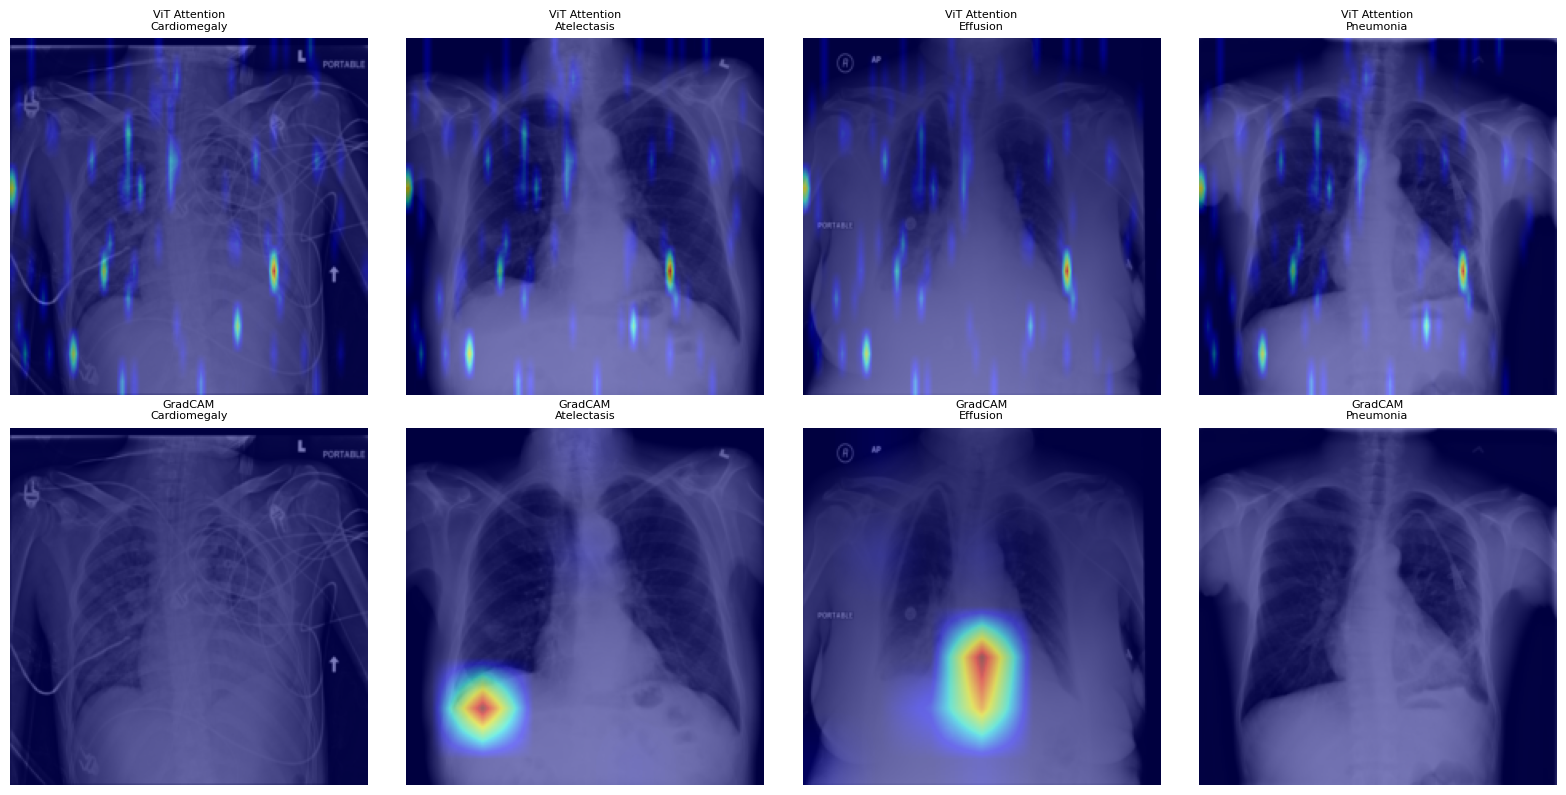

In [14]:
import matplotlib.pyplot as plt
from src.explainability import denormalise, overlay_attention

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    img = denormalise(id_samples[i]['tensor'])
    axes[0, i].imshow(overlay_attention(img, id_attention[i]))
    axes[0, i].set_title(f'ViT Attention\n{id_samples[i]["finding"]}', fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(overlay_attention(img, id_gradcam[i]))
    axes[1, i].set_title(f'GradCAM\n{id_samples[i]["finding"]}', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()